<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **End-to-End Example: Transfer Learning**


### Importing Required Libraries


In [1]:
import os
import random
import shutil
import glob
import warnings
import datetime

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.image import imread

warnings.simplefilter("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("TensorFlow Version:", tf.__version__)

# Keras (use tensorflow.keras consistently)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Flatten,
    Dense,
    Dropout,
    Input,
    InputLayer
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import optimizers

# Scikit-learn
from sklearn import metrics

# Plot settings
sns.set_context("notebook")
sns.set_style("white")

TensorFlow Version: 2.21.0


## Example 1: Create a ML model for distinguishing recyclable and organic waste images


In [2]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
n_classes = 2
val_split = 0.2
seed= 10

path = "o-vs-r-split/train"
path_test = "o-vs-r-split/test"

input_shape = (img_rows, img_cols, 3)
labels = ["O", "R"]

checkpoint_path = "ORnet.keras"

In [3]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
n_classes = 2
val_split = 0.2
verbosity = 1
path = 'o-vs-r-split/train/'
path_test = 'o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3) #RGB
labels = ['O', 'R']
seed = 10
checkpoint_path='ORnet.h5'

### Loading Images using ImageGeneratorClass


Transfer learning works best when models are trained on smaller datasets. We are using 10,000 images from the original dataset of 25,000 images. We are setting aside 10% of the set for testing purposes.


The folder structure looks as follows:


```python
o-vs-r-split/
└── train
    ├── O
    └── R
└── test
    ├── O
    └── R
```


#### Image Augmentation


Now we will create ImageDataGenerators used for training, validation, and testing.

Image data generators create batches of tensor image data with real-time data augmentation. They loop over the data in batches and are useful in feeding data to the training process. We specify a 20% validation split.

We will perform a few image augmentation steps. We set __rescale__ to 1./255. This means that each image pixel will be divided by 255 in order to normalize the image. We set the __width_shift_range__ and __height_shift_range__ to 0.1 each, and the __horizontal_flip__ to True. 
* The __width_shift_range__ shifts the image horizontally (left or right). 
* The __height_shift_range__ shifts the image vertically (up or down). 
* The __horizontal_flip__ randomly flip inputs horizontally.


In [4]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

Since it is undesirable to load all of our image data into memory all at once, we make use of the __flow_from_directory__ method. It takes the ImageDataGenerator training/validation sets and flows image batches from a specified folder. 

* We set __directory__ to the __path__, specifying the path to our training dataset. 
* We specify classes using __labels__ we had defined in the configuration step.
* We apply a __seed__ so our random initializer is generated in the same way each time we perform this step. This allows for direct comparison between experiments.


In [5]:
# use the labels defined before to 
# find number of images belonging to each category
train_generator = train_datagen.flow_from_directory(
    directory = path,
    classes = labels,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'training'
)

Found 5810 images belonging to 2 classes.


In [6]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    classes = labels,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_rows),
    subset = 'validation'
)

Found 1452 images belonging to 2 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    directory = path_test,
    classes = labels,
    class_mode='binary',
    seed = seed,
    batch_size = batch_size, 
    shuffle = True,
    target_size=(img_rows, img_rows)
)

Found 828 images belonging to 2 classes.


There were 5810 images belonging to 2 classes found in the train directory, and 1452 images belonging to the same two classes were found in the validation directory, and 828 images were found in the test set.


Let's look at a few augmented images:


Labels: [np.str_('O\\O_10'), np.str_('O\\O_10'), np.str_('O\\O_10'), np.str_('O\\O_10'), np.str_('O\\O_10')]


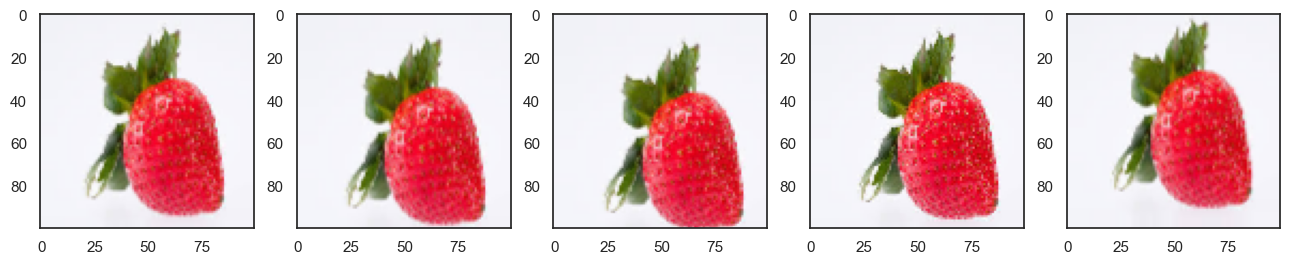

In [9]:
IMG_DIM = (100, 100)

train_files = glob.glob('./o-vs-r-split/train/O/*')
train_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in train_files]
train_imgs = np.array(train_imgs)
train_labels = [fn.split('/')[3].split('.')[0].strip() for fn in train_files]

img_id = 0
O_generator = train_datagen.flow(train_imgs[img_id:img_id+1], train_labels[img_id:img_id+1],
                                   batch_size=1)
O = [next(O_generator) for i in range(0,5)]
fig, ax = plt.subplots(1,5, figsize=(16, 6))
print('Labels:', [item[1][0] for item in O])
l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]


### Pre-trained Models


Pre-trained models are saved networks that have previously been trained on some large (somewhat related) datasets. They are typically used for a large-scale image-classification task. They can be used as they are or could be customized to a given task using transfer learning. These pre-trained models form the basis of transfer learning.


We can leverage a pre-trained model's weighted layers to extract generic features. In this step we would not update the model's layers weights during training. This helps us utilize the knowledge from a source-domain task.


Fine-tuning, which is a more involved process, involves more than just replacing the final layer. We also try to retrain some of the previous layers.


In computer vision, some popular pre-trained models include: VGG-16, VGG-19, InceptionV3, XCeption, and ResNet-50.


#### VGG-16


Let us load the VGG16 model.

```python
tf.keras.applications.VGG16(
    include_top=True,
    weights="imagenet",
    input_shape=None,
)
```
The default input image size for this model is 224x224.

Further information on arguments can be found in the Keras [documentation](https://keras.io/api/applications/vgg/).

>Note: Each Keras Application expects a specific kind of input preprocessing. For VGG16, call `tf.keras.applications.vgg16.preprocess_input` on your inputs before passing them to the `model.vgg16.preprocess_input` will convert the input images from RGB to BGR, then will zero-center each color channel with respect to the ImageNet dataset, without scaling.

>* __include_top__: whether to include the fully-connected layer at the top of the network.
>* __weights__: one of None (random initialization), 'imagenet' (pre-trained on ImageNet), or the path to the weights file to be loaded.
>* __input_shape__: optional shape tuple, only to be specified if include_top is False (otherwise the input shape has to be (224, 224, 3). 


First we load the model 


In [10]:
from keras.applications import vgg16
input_shape = (150, 150, 3)

vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)



We flatten the output of a vgg model and assign it to the model ```output```, we then use a Model object ```basemodel``` to group the layers into an object for training and inference .
With the following inputs and outputs  

inputs: ```vgg.input```

outputs: ```tf.keras.layers.Flatten()(output)```


In [11]:
output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

Next, we freeze the basemodel, like the lower layers.


In [12]:
basemodel.trainable = False
for layer in basemodel.layers: layer.trainable = False

Create a new model on top. We add a Dropout layer for regularization, only these layers will change as for the lower layers we set `training=False` when calling the base model.


In [13]:
input_shape = basemodel.output_shape[1]

model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu', input_dim=input_shape))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

Let us print the model summary.


In [14]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


### Compile the model


Calling `compile()` freezes the behavior of that model, implying that the trainable attribute values at the time of compilation are preserved.


We use RMSProp as our optimizer with a learning rate of 2e-5, Binary Cross Entropy Loss as our loss function and Accuracy as our primary metric for model evaluation as we have 2 labels in our dataset.


In [15]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=2e-5),
              metrics=['accuracy'])


We use early stopping to avoid over-training the model. An over-trained model overfits the training dataset and has poor performance on unseen test sets. We will also use a exponential step-decay based learning rate scheduler.


In [16]:
from tensorflow.keras.callbacks import Callback

In [17]:
from tensorflow import keras
from tensorflow.keras.callbacks import (
    Callback,
    LearningRateScheduler,
    EarlyStopping,
    ModelCheckpoint
)

checkpoint_path = "O_R_tlearn_image_augm_cnn_vgg16.keras"

def exp_decay(epoch):
    initial_lrate = 1e-5
    k = 0.1
    return initial_lrate * np.exp(-k * epoch)

class LossHistory_(Callback):
    def on_train_begin(self, logs=None):
        self.losses = []
        self.lr = []

    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs.get("loss"))
        self.lr.append(exp_decay(epoch + 1))
        print("lr:", exp_decay(epoch + 1))

loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
    EarlyStopping(
        monitor="loss",
        patience=5,
        mode="min",
        min_delta=0.01
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor="loss",
        save_best_only=True,
        mode="min"
    )
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

In [18]:
from keras.callbacks import LearningRateScheduler
checkpoint_path='O_R_tlearn_image_augm_cnn_vgg16.h5'

# define step decay function
class LossHistory_(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.lr = []
        
    def on_epoch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))
        self.lr.append(exp_decay(len(self.losses)))
        print('lr:', exp_decay(len(self.losses)))

def exp_decay(epoch):
    initial_lrate = 1e-5
    k = 0.1
    lrate = initial_lrate * np.exp(-k*epoch)
    return lrate

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'loss', 
                    patience = 5, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_, keras_callbacks]

In [19]:
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

print("Class indices:", train_generator.class_indices)

Train samples: 5810
Validation samples: 1452
Test samples: 828
Class indices: {'O': 0, 'R': 1}


### Fit and train the model


In [20]:
extract_feat_model = model.fit(train_generator, 
                              steps_per_epoch=10, 
                              epochs=5,
                              validation_data=val_generator, 
                              validation_steps=10, 
                              verbose=1,
                              callbacks = callbacks_list_)  

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4784 - loss: 0.7257

lr: 9.048374180359596e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.5281 - loss: 0.6964 - val_accuracy: 0.5906 - val_loss: 0.6594 - learning_rate: 1.0000e-05
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5212 - loss: 0.7137lr: 8.18730753077982e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5250 - loss: 0.7100 - val_accuracy: 0.7156 - val_loss: 0.6243 - learning_rate: 9.0484e-06
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5747 - loss: 0.6732

lr: 7.408182206817179e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.6094 - loss: 0.6544 - val_accuracy: 0.7563 - val_loss: 0.6039 - learning_rate: 8.1873e-06
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6589 - loss: 0.6121

lr: 6.703200460356394e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6438 - loss: 0.6244 - val_accuracy: 0.7656 - val_loss: 0.5788 - learning_rate: 7.4082e-06
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6641 - loss: 0.6051lr: 6.065306597126334e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6667 - loss: 0.6277 - val_accuracy: 0.8156 - val_loss: 0.5630 - learning_rate: 6.7032e-06


### Fine-Tuning


Fine-tuning is an optional step in transfer learning, it usually ends up improving the performance of the model. It is easy to overfit the model in this step as we are re-training the entire model. So we use regularization (dropout layers), a lower learning rate, a small number of epochs (training iterations), and early stopping to know when the model has stopped improving and to prevent overfitting. 


In order to fine-tune our model, we will use the VGG-16 model object stored in the `basemodel` variable. We will unfreeze convolution blocks 4 and 5 and keep the first 3 blocks frozen. This ensures that the convolution and pooling layers for blocks 4 and 5 are trainable; that is, weights get updated through backpropagation in each training iteration or epoch.


We can find the name of each layer


In [21]:
[layer.name for layer in basemodel.layers]

['input_layer',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_pool',
 'flatten']

we then set ```'block5_conv1'```and ```'block4_conv1' ``` to trainable


In [22]:
basemodel.trainable = True

set_trainable = False

for layer in basemodel.layers:
    if layer.name in ['block5_conv1', 'block4_conv1']:
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

Similar to what we did before, we create a new model on top, add a Dropout layer for regularization, and set `training=False` when calling the base model.


In [23]:
model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu', input_dim=input_shape))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

checkpoint_path='O_R_tlearn_image_augm_fine_tune_vgg16.h5'


# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'loss', 
                    patience = 5, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_, keras_callbacks]

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-5),
              metrics=['accuracy'])
              
fine_tune_model = model.fit(train_generator, 
                    steps_per_epoch=10, 
                    epochs=5,
                    callbacks = callbacks_list_,   
                    validation_data=val_generator, 
                    validation_steps=10, 
                    verbose=1)       

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5095 - loss: 0.7849

lr: 9.048374180359596e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.5125 - loss: 0.7548 - val_accuracy: 0.6750 - val_loss: 0.6121 - learning_rate: 1.0000e-05
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5848 - loss: 0.6528

lr: 8.18730753077982e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.6062 - loss: 0.6432 - val_accuracy: 0.8000 - val_loss: 0.5471 - learning_rate: 9.0484e-06
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6970 - loss: 0.5712

lr: 7.408182206817179e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 55s 6s/step - accuracy: 0.7281 - loss: 0.5403 - val_accuracy: 0.8125 - val_loss: 0.5028 - learning_rate: 8.1873e-06
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7208 - loss: 0.5330

lr: 6.703200460356394e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.7344 - loss: 0.5111 - val_accuracy: 0.8344 - val_loss: 0.4462 - learning_rate: 7.4082e-06
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7488 - loss: 0.5101lr: 6.065306597126334e-06
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.7594 - loss: 0.5189 - val_accuracy: 0.8344 - val_loss: 0.4299 - learning_rate: 6.7032e-06


The fine tuned model has a validation accuracy higher than the previous transfer learning model.


### Evaluate both models on test data


Load saved models:


In [24]:
extract_feat_model = tf.keras.models.load_model('O_R_tlearn_image_augm_cnn_vgg16.h5')
fine_tune_model = tf.keras.models.load_model('O_R_tlearn_image_augm_fine_tune_vgg16.h5')

Load test images:


In [25]:
from sklearn.utils import shuffle


IMG_DIM = (150, 150)

# Read in all O and R test images file paths. Shuffle and select 50 random test images. 
test_files_O = glob.glob('./o-vs-r-split/test/O/*')
test_files_R = glob.glob('./o-vs-r-split/test/R/*')
test_files = test_files_O + test_files_R
test_files = shuffle(test_files)[0:50]

# Extract label from file path
test_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in test_files]
test_imgs = np.array(test_imgs)
test_labels = [fn.split('/')[3].split('.')[0].strip() for fn in test_files]

# Standardize
test_imgs_scaled = test_imgs.astype('float32')
test_imgs_scaled /= 255

In [26]:
class2num_lt = lambda l: [0 if x == 'O' else 1 for x in l]
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]

test_labels_enc = class2num_lt(test_labels)

In [27]:
predictions_extract_feat_model = extract_feat_model.predict(test_imgs_scaled, verbose=0)
predictions_fine_tune_model = fine_tune_model.predict(test_imgs_scaled, verbose=0)

In [28]:
predictions_extract_feat_model = num2class_lt(predictions_extract_feat_model)
predictions_fine_tune_model = num2class_lt(predictions_fine_tune_model)

In [29]:
print('Extract Features Model')
print(metrics.classification_report(test_labels, predictions_extract_feat_model))
print('Fine-Tuned Model')
print(metrics.classification_report(test_labels, predictions_fine_tune_model))

Extract Features Model
              precision    recall  f1-score   support

           O       0.00      0.00      0.00       0.0
    O\O_1021       0.00      0.00      0.00       1.0
   O\O_10242       0.00      0.00      0.00       1.0
   O\O_10398       0.00      0.00      0.00       1.0
   O\O_11425       0.00      0.00      0.00       1.0
   O\O_11540       0.00      0.00      0.00       1.0
    O\O_1228       0.00      0.00      0.00       1.0
    O\O_1981       0.00      0.00      0.00       1.0
    O\O_2335       0.00      0.00      0.00       1.0
    O\O_2406       0.00      0.00      0.00       1.0
    O\O_2411       0.00      0.00      0.00       1.0
    O\O_2487       0.00      0.00      0.00       1.0
    O\O_2553       0.00      0.00      0.00       1.0
    O\O_2658       0.00      0.00      0.00       1.0
    O\O_2753       0.00      0.00      0.00       1.0
    O\O_3498       0.00      0.00      0.00       1.0
    O\O_4645       0.00      0.00      0.00       1.0
    

#### Custom image: is your waste organic or a recyclable?


['O']

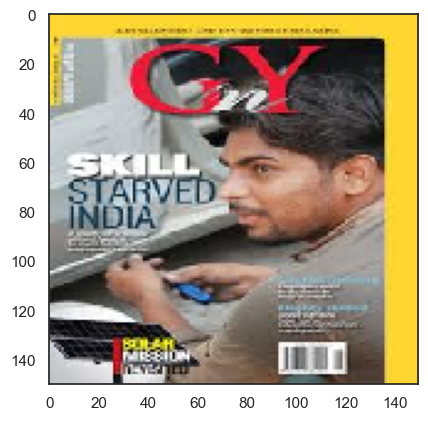

In [30]:
custom_im = test_imgs_scaled[2]
plt.imshow(custom_im)

num2class_lt(extract_feat_model.predict(custom_im.reshape((1,
                                                           test_imgs_scaled.shape[1], 
                                                           test_imgs_scaled.shape[2], 
                                                           test_imgs_scaled.shape[3])), verbose=0))

['O']

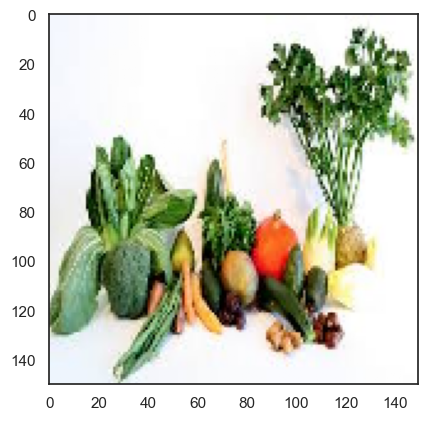

In [31]:
custom_im = test_imgs_scaled[3]
plt.imshow(custom_im)

num2class_lt(extract_feat_model.predict(custom_im.reshape((1,
                                                           test_imgs_scaled.shape[1], 
                                                           test_imgs_scaled.shape[2], 
                                                           test_imgs_scaled.shape[3])), verbose=0))

Now we are all set to see if our waste product is an organic or a recyclable.
